# <font color="White"> Prática 01: Perceptron Learning Algorithm (PLA) </font>




**Objetivos:**


*   Entender o funcionamento do PLA e dos componentes de aprendizagem.
*   Fixar o conceito de aprendizagem.



**Descrição:**

Crie uma dataset $D$ com 1000 pontos e uma função alvo $f$ para compreender o funcionamento do PLA. Para visualizar os passos do algoritmo, considere $d=2$ e assuma $X=[-1,1]\times[-1,1]$, em que $x\in X$ é escolhido com probabilidade uniforme. Escolha uma reta como função alvo, em que um lado da reta seja mapeado para $+1$ e o outro para $-1$. Gere então pontos aleatórios $x_i$ e obtenha sua classificação $y_i$ a partir da função alvo. Divida os dados em um grupo de treinamento e outro de teste.

Após a preparação dos dados, crie uma função $PLA()$ que inicia com os pesos todos iguais a zero e, a cada iteração, deixe o algoritmo escolher aleatoriamente um dos pontos com classificação incorreta até que ele convirja. Rode o PLA sobre subamostras com $N=10$ e $N=100$, teste a hipótese solução a partir de pontos ainda não vistos (conjunto de teste) e responda a seguinte questão:

- Qual o percentual de pontos classificados corretamente para cada hipótese solução nos conjuntos de treinamento e teste?










# <font color="White"> Solução </font>


###  Preparação dos dos dados

O objetivo da prepação dos dados é a criação da função alvo e do dataset conforme a descrição do problema. Para tanto, você deve realizar os seguintes passos:

* Crie a função alvo (uma reta) a partir de dois pontos gerados aleatoriamente;
* Calcule o coeficiente angular e o coeficiente linear (bias) e os armazene em variáveis distintas;
* Gere aleatoriamente 1000 pontos, cujas coordenadas estão no intervalo $[-1,1]$, e os adicione em uma lista $X$ correspondendo aos dados da amostra;
* Para cada ponto gerado, use a função sign() de numpy, que recebe como entrada uma reta (função alvo), para obter a classificação de cada ponto. Adicione cada classificação em uma lista $y$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output

# Crie a funcao alvo e o dataset

def cria_funcao_alvo():
    # pontos aleatorios no quadrado [-1,1] x [-1,1]
    p1 = list(np.random.uniform(-1, 1, 2))
    p2 = list(np.random.uniform(-1, 1, 2))
    # calcula coeficiente angular m e b da reta y = m*x + b
    while p2[0] == p1[0]:
        p2 = list(np.random.uniform(-1, 1, 2))
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    b = p1[1] - m * p1[0]
    return p1, p2, m, b

def gera_dataset(n_points, m, b, seed=None):
    if seed is not None:
        np.random.seed(seed)
    X = np.random.uniform(-1, 1, (n_points, 2))
    # label: +1 se acima da reta y = m*x + b, -1 caso contrario
    y_raw = X[:,1] - (m * X[:,0] + b)
    y = np.sign(y_raw)
    y[y == 0] = 1

    return X.tolist(), y.tolist()


### Visualizando o dataset
Use a função abaixo para visualizar o dataset criado anteriormente.

In [ ]:
def show_dataset(X, y, p1, p2, m, b):
    """
    Esta função tem o objetivo de exibir na tela uma amostra do dataset passado por parâmetro.

    Paramêtros:
    - X (matriz): Matriz 1000x2 correspondendo aos dados amostra. Cada elemento de X é uma lista que corresponde
    às coordenadas dos pontos gerados.
    - y (list): Classificação dos pontos da amostra X.
    - p1 (list): Coordenadas do ponto p1 gerado para criar a função alvo.
    - p2 (list): Coordenadas do ponto p2 gerado para criar a função alvo.
    - m (float): Coeficiente angular da função alvo.
    - b (float): Coeficidnte linear da função alvo.
    """

    line = np.linspace(-1, 1, 1000)
    plt.plot(line, m*line + b, label="f(x)", c="green")

    # Pontos usados na criacao da reta
    plt.scatter(p1[0], p1[1], c='green')
    plt.scatter(p2[0], p2[1], c='green')

    for i in range(len(X[:200])):
        if (y[i] == 1):
            plt.scatter(X[i][0], X[i][1], c='blue')
        else:
            plt.scatter(X[i][0], X[i][1], c='red')

    plt.show()


### Algoritmo PLA
Complete a função PLA() abaixo para implementar o Algoritmo de Aprendizagem do Perceptron conforme os slides da aula de "Significado de aprendizagem".

In [ ]:
def PLA(X, y, f, plot_steps=False, max_iters=10000):
    """
    Esta função corresponde ao Algoritmo de Aprendizagem do modelo Perceptron.

    Paramêtros:
    - X (list[]): Matriz correspondendo aos dados amostra. Cada elemento de X é uma lista que corresponde
    às coordenadas dos pontos gerados.
    - y (list): Classificação dos pontos da amostra X.
    - f (list): Lista de dois elementos correspondendo, respectivamente, aos coeficientes angular e linear
    da função alvo.

    Retorno:
    - it (int): Quantidade de iterações necessárias para corrigir todos os pontos classificados incorretamente.
    - w (list): Lista de três elementos correspondendo aos pesos do perceptron.
    """
    N = len(X)
    w = np.zeros(3)  # w0 (bias), w1, w2
    it = 0

    # lista de pontos classificados incorretamente
    l, _ = constroiListaPCI(X, y, w)

    # Enquanto houver pontos classificados incorretamente e nao exceder max_iters
    while len(l) > 0 and it < max_iters:
        idx = random.choice(l)#escolha aleatória dos índices
        xi = np.array([1, X[idx][0], X[idx][1]])
        yi = y[idx]
        # atualiza pesos
        w = w + yi * xi
        it += 1

        # atualiza lista de pontos incorretos
        l, _ = constroiListaPCI(X, y, w)

        if plot_steps:
            plot_grafico(X, y, w, f)

    return it, w

### Função para visualização dos passos do PLA
A função abaixo é uma função auxiliar que permite que vocês enxerguem o resultado de cada iteração da função PLA().

In [ ]:
%matplotlib inline
def plot_grafico(X, y, w, f):
    """
    Esta função objetiva a visualização dos passos do PLA.

    Parâmetros:
    - X: Matriz dos dados da amostra.
    - y: Classificação (+1 ou -1) dos pontos.
    - w: Pesos do perceptron [bias, w1, w2].
    - f: [m, b] coeficiente angular e linear da função alvo.
    """
    nPontos = len(X)
    ax = plt.gca()
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['right'].set_color('none')

    plt.axis([-1, 1, -1, 1])

    x_plt = [X[i][0] for i in range(nPontos)]
    y_plt = [X[i][1] for i in range(nPontos)]

    for i in range(nPontos):
        if (y[i] == 1):
            plt.scatter(x_plt[i], y_plt[i], s=10, c='blue')
        else:
            plt.scatter(x_plt[i], y_plt[i], s=10, c='red')

    x = np.linspace(-1, 1, 1000)
    plt.plot(x, f[0]*x + f[1], c='green') # f[0] = m, f[1] = b

    # se w ainda nao inicializado direito, evita a divisão por zero
    if w is not None and len(w) == 3 and w[2] != 0:
        plt.plot(x, (-w[0] - w[1]*x) / w[2], c='orange') # A*x + B*y + C => y = (-C - A*x) / B

    clear_output(wait=True)
    plt.show(block=False)
    plt.pause(0.01)

### Função para construir lista de pontos classificados incorretamente
Implemente a função abaixo para contruir a lista de pontos classificados incorretamente em cada iteração do loop principal da função PLA().


In [ ]:
def constroiListaPCI(X, y, w):
    """
    Esta função constrói a lista de pontos classificados incorretamente.

    Parâmetros:
    - X: matriz Nx2 com os pontos da amostra.
    - y: vetor com as classificações dos pontos.
    - w: pesos atuais do perceptron (bias, w1, w2).

    Retorno:
    - l: lista dos pontos X[i] que foram classificados incorretamente.
    - new_y: lista das classificações verdadeiras desses pontos.
    """

    l = []
    new_y = []
    # w é lista [w0, w1, w2]; cada x é [x1, x2]
    for i, xi in enumerate(X):
        x_aug = np.array([1, xi[0], xi[1]])
        # sinal da predição
        pred = np.sign(np.dot(w, x_aug))
        if pred == 0:
            pred = 1
        if pred != y[i]:
            l.append(i)
            new_y.append(y[i])
    return l, new_y

### Calculando a acurácia

Treine o Modelo de Aprendizagem de Máquina Perceptron com subamostras de tamanhos $N=10$ e $N = 100$, conforme o enunciado, e em seguida verifique a acurácia do modelo com uma subamostra de teste, com pelo menos 100 pontos,
que contém pontos diferentes das subamostras utilizadas para treinamento.

Pontos usados para definir a função alvo: [np.float64(-0.738261875273335), np.float64(-0.9990218633515344)] [np.float64(-0.4996620579830773), np.float64(-0.08099144244554402)]
Reta: y = 3.8476 x + 1.8415


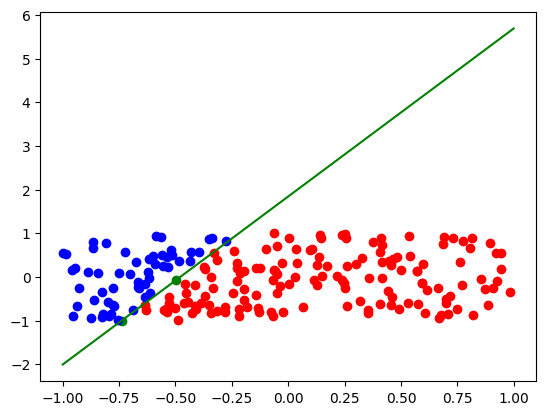

PLA (N=10) convergiu em 17 iterações. Pesos: [-1.         -1.80975283  1.10799809]
PLA (N=100) convergiu em 30 iterações. Pesos: [-2.         -4.18698316  1.07811868]

Resultados:
N=10: Acurácia treino = 100.00%, Acurácia teste = 96.00%
N=100: Acurácia treino = 100.00%, Acurácia teste = 100.00%


In [ ]:
# Treinar o PLA com N = 10 e N = 100 e calcular acurácia
def acuracia(X, y, w):
    """
    Retorna percentagem de pontos classificados corretamente (0-100)
    """
    X_arr = np.array(X)
    N = len(X)
    hits = 0
    for i in range(N):
        x_aug = np.array([1, X[i][0], X[i][1]])
        pred = np.sign(np.dot(w, x_aug))
        if pred == 0:
            pred = 1
        if pred == y[i]:
            hits += 1
    return 100.0 * hits / N


# cria funcao alvo
p1, p2, m, b = cria_funcao_alvo()
f = [m, b]

#gera dataset total (1000 pontos)
X_all, y_all = gera_dataset(1000, m, b, seed=None)

# Visualiza amostra inicial
print("Pontos usados para definir a função alvo:", p1, p2)
print("Reta: y = {:.4f} x + {:.4f}".format(m, b))
show_dataset(X_all, y_all, p1, p2, m, b)

#cria subamostras de treino N=10 e N=100 e um conjunto de teste de 100 pontos
indices = list(range(len(X_all)))
random.shuffle(indices)

# usa primeiros 1000 aleatorios para garantir separação
train10_idx = indices[:10]
train100_idx = indices[:100]
test_idx = indices[100:200]

X10 = [X_all[i] for i in train10_idx]
y10 = [y_all[i] for i in train10_idx]

X100 = [X_all[i] for i in train100_idx]
y100 = [y_all[i] for i in train100_idx]

Xtest = [X_all[i] for i in test_idx]
ytest = [y_all[i] for i in test_idx]

# treina PLA para N=10
it10, w10 = PLA(X10, y10, f, plot_steps=False)
print(f"PLA (N=10) convergiu em {it10} iterações. Pesos: {w10}")

# treina PLA para N=100
it100, w100 = PLA(X100, y100, f, plot_steps=False)
print(f"PLA (N=100) convergiu em {it100} iterações. Pesos: {w100}")

# avalia acurácia nos conjuntos de treinamento e teste
acc10_train = acuracia(X10, y10, w10)
acc10_test  = acuracia(Xtest, ytest, w10)

acc100_train = acuracia(X100, y100, w100)
acc100_test  = acuracia(Xtest, ytest, w100)

print("\nResultados:")
print(f"N=10: Acurácia treino = {acc10_train:.2f}%, Acurácia teste = {acc10_test:.2f}%")
print(f"N=100: Acurácia treino = {acc100_train:.2f}%, Acurácia teste = {acc100_test:.2f}%")
